# 08 — Inference Profiling (CPU)

**Goal:** Profile the full inference pipeline on CPU to determine:
1. Can we afford a 5-model ensemble within 90 minutes?
2. ONNX vs PyTorch vs Quantized ONNX — which is fastest?
3. Memory usage — will it fit in Kaggle's ~13 GB RAM limit?
4. **Decision:** optimal inference strategy for submission.

In [1]:
import os, sys, time, warnings
os.chdir(os.path.join(os.path.dirname(os.getcwd()), ''))  # project root
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn

try:
    import onnxruntime as ort
    print(f'onnxruntime version: {ort.__version__}')
except ImportError:
    print('Installing onnxruntime...')
    os.system('pip install onnxruntime --quiet')
    import onnxruntime as ort

import librosa
from pathlib import Path

print(f'CPU count: {os.cpu_count()}')
print(f'RAM: {psutil.virtual_memory().total / 1024**3:.1f} GB')
print(f'Available RAM: {psutil.virtual_memory().available / 1024**3:.1f} GB')

onnxruntime version: 1.24.4
CPU count: 16
RAM: 15.0 GB
Available RAM: 6.3 GB


## 1. Configuration (must match training)

In [2]:
# Spectrogram parameters — MUST match training exactly
SAMPLE_RATE = 32000
N_MELS = 128
FMAX = 16000
HOP_LENGTH = 512
N_FFT = 2048
WINDOW_SECONDS = 5.0
WINDOW_SAMPLES = int(SAMPLE_RATE * WINDOW_SECONDS)  # 160000
NUM_CLASSES = 234
SPEC_TIME_FRAMES = 313  # expected time dimension

INPUT_SHAPE = (1, 1, N_MELS, SPEC_TIME_FRAMES)

# Paths
EXP_ROOT = Path('experiments')
AUDIO_DIR = Path('data/raw/train_audio')
TRAIN_CSV = Path('data/raw/train.csv')
SAMPLE_SUB = Path('data/raw/sample_submission.csv')

# Load species list
if SAMPLE_SUB.exists():
    sample = pd.read_csv(SAMPLE_SUB)
    species_list = [c for c in sample.columns if c != 'row_id']
else:
    meta = pd.read_csv(TRAIN_CSV)
    species_list = sorted(meta['primary_label'].unique().tolist())

print(f'Species: {len(species_list)}')
print(f'Input shape: {INPUT_SHAPE}')

Species: 234
Input shape: (1, 1, 128, 313)


## 2. Generate synthetic test audio

We'll create synthetic soundscapes to profile the pipeline without needing actual test data.

In [3]:
# Create synthetic test soundscapes for profiling
PROFILE_DIR = Path('/tmp/profile_soundscapes')
PROFILE_DIR.mkdir(exist_ok=True)

import soundfile as sf

N_SYNTHETIC = 2  # number of synthetic soundscapes
SOUNDSCAPE_DURATION = 60  # 4 minutes each (typical BirdCLEF soundscape)

for i in range(N_SYNTHETIC):
    # Random noise to simulate audio (actual content doesn't matter for timing)
    y = np.random.randn(SAMPLE_RATE * SOUNDSCAPE_DURATION).astype(np.float32) * 0.01
    fpath = PROFILE_DIR / f'soundscape_test_{i:03d}.ogg'
    sf.write(str(fpath), y, SAMPLE_RATE, format='OGG', subtype='VORBIS')

print(f'Created {N_SYNTHETIC} synthetic soundscapes ({SOUNDSCAPE_DURATION}s each)')
print(f'Expected windows per soundscape: {SOUNDSCAPE_DURATION // int(WINDOW_SECONDS)}')
print(f'Total windows: {N_SYNTHETIC * (SOUNDSCAPE_DURATION // int(WINDOW_SECONDS))}')

Created 2 synthetic soundscapes (60s each)
Expected windows per soundscape: 12
Total windows: 24


## 3. Profile individual stages

In [4]:
# --- 3a. Audio loading time ---
audio_files = sorted(PROFILE_DIR.glob('*.ogg'))

load_times = []
for f in audio_files:
    t0 = time.perf_counter()
    y, sr = librosa.load(str(f), sr=SAMPLE_RATE, mono=True)
    load_times.append(time.perf_counter() - t0)
    print(f'  {f.name}: {load_times[-1]:.2f}s, {len(y)/SAMPLE_RATE:.0f}s audio, '
          f'{len(y)/1e6:.1f}M samples')

print(f'\nAudio load: mean={np.mean(load_times):.2f}s, '
      f'total for {N_SYNTHETIC} files = {sum(load_times):.2f}s')

  soundscape_test_000.ogg: 1.58s, 60s audio, 1.9M samples
  soundscape_test_001.ogg: 0.03s, 60s audio, 1.9M samples

Audio load: mean=0.81s, total for 2 files = 1.62s


In [5]:
# --- 3b. Spectrogram computation time ---
# Load one soundscape and time spectrogram per window
y = librosa.load(str(audio_files[0]), sr=SAMPLE_RATE, mono=True)[0]
n_windows = len(y) // WINDOW_SAMPLES

spec_times = []
for i in range(min(n_windows, 100)):  # profile up to 100 windows
    segment = y[i * WINDOW_SAMPLES : (i + 1) * WINDOW_SAMPLES]
    
    t0 = time.perf_counter()
    S = librosa.feature.melspectrogram(
        y=segment, sr=SAMPLE_RATE,
        n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmax=FMAX
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    
    # Pad/trim to target
    if S_db.shape[1] >= SPEC_TIME_FRAMES:
        S_db = S_db[:, :SPEC_TIME_FRAMES]
    else:
        S_db = np.pad(S_db, ((0,0), (0, SPEC_TIME_FRAMES - S_db.shape[1])),
                      mode='constant', constant_values=S_db.min())
    
    spec_times.append(time.perf_counter() - t0)

print(f'Spectrogram per window: mean={np.mean(spec_times)*1000:.2f}ms, '
      f'std={np.std(spec_times)*1000:.2f}ms')
print(f'Spectrogram shape: {S_db.shape}')

Spectrogram per window: mean=14.25ms, std=12.41ms
Spectrogram shape: (128, 313)


## 4. Model inference comparison: PyTorch vs ONNX vs Quantized

In [6]:
# Discover available models
model_formats = {}

for fold_id in range(5):
    fold_dir = EXP_ROOT / f'baseline_effb0_fold{fold_id}'
    pt_path = fold_dir / 'best_model.pt'
    onnx_path = fold_dir / 'best_model.onnx'
    quant_path = fold_dir / 'best_model_quantized.onnx'
    
    if pt_path.exists():
        model_formats.setdefault('pytorch', []).append(pt_path)
    if onnx_path.exists():
        model_formats.setdefault('onnx', []).append(onnx_path)
    if quant_path.exists():
        model_formats.setdefault('quantized', []).append(quant_path)

print('Available models:')
for fmt, paths in model_formats.items():
    sizes = [os.path.getsize(p)/1024/1024 for p in paths]
    print(f'  {fmt}: {len(paths)} folds, avg size = {np.mean(sizes):.1f} MB')

Available models:
  pytorch: 5 folds, avg size = 49.7 MB
  onnx: 5 folds, avg size = 16.5 MB
  quantized: 5 folds, avg size = 4.5 MB


In [7]:
# Benchmark each format
N_WARMUP = 10
N_BENCH = 50
dummy_input = np.random.randn(*INPUT_SHAPE).astype(np.float32)
dummy_torch = torch.from_numpy(dummy_input)

results = {}

# --- PyTorch ---
if 'pytorch' in model_formats:
    from src.training.train import BirdCLEFModel
    
    pt_path = model_formats['pytorch'][0]
    model_pt = BirdCLEFModel(backbone='tf_efficientnet_b0', num_classes=NUM_CLASSES,
                             dropout=0.3, pretrained=False)
    state = torch.load(str(pt_path), map_location='cpu', weights_only=False)
    if 'model_state_dict' in state:
        model_pt.load_state_dict(state['model_state_dict'])
    elif 'state_dict' in state:
        model_pt.load_state_dict(state['state_dict'])
    else:
        model_pt.load_state_dict(state)
    model_pt.eval()
    
    # Warmup
    with torch.no_grad():
        for _ in range(N_WARMUP):
            model_pt(dummy_torch)
    
    # Bench
    times_pt = []
    with torch.no_grad():
        for _ in range(N_BENCH):
            t0 = time.perf_counter()
            model_pt(dummy_torch)
            times_pt.append(time.perf_counter() - t0)
    
    results['PyTorch'] = np.array(times_pt) * 1000
    del model_pt
    print(f'PyTorch:   mean={np.mean(results["PyTorch"]):.2f}ms, '
          f'p95={np.percentile(results["PyTorch"], 95):.2f}ms')

# --- ONNX ---
if 'onnx' in model_formats:
    sess_onnx = ort.InferenceSession(
        str(model_formats['onnx'][0]), providers=['CPUExecutionProvider'])
    
    for _ in range(N_WARMUP):
        sess_onnx.run(None, {'input': dummy_input})
    
    times_onnx = []
    for _ in range(N_BENCH):
        t0 = time.perf_counter()
        sess_onnx.run(None, {'input': dummy_input})
        times_onnx.append(time.perf_counter() - t0)
    
    results['ONNX'] = np.array(times_onnx) * 1000
    del sess_onnx
    print(f'ONNX:      mean={np.mean(results["ONNX"]):.2f}ms, '
          f'p95={np.percentile(results["ONNX"], 95):.2f}ms')

# --- Quantized ONNX ---
if 'quantized' in model_formats:
    sess_q = ort.InferenceSession(
        str(model_formats['quantized'][0]), providers=['CPUExecutionProvider'])
    
    for _ in range(N_WARMUP):
        sess_q.run(None, {'input': dummy_input})
    
    times_q = []
    for _ in range(N_BENCH):
        t0 = time.perf_counter()
        sess_q.run(None, {'input': dummy_input})
        times_q.append(time.perf_counter() - t0)
    
    results['Quantized ONNX'] = np.array(times_q) * 1000
    del sess_q
    print(f'Quantized: mean={np.mean(results["Quantized ONNX"]):.2f}ms, '
          f'p95={np.percentile(results["Quantized ONNX"], 95):.2f}ms')

PyTorch:   mean=23.12ms, p95=30.63ms
ONNX:      mean=13.66ms, p95=20.17ms
Quantized: mean=32.21ms, p95=41.65ms


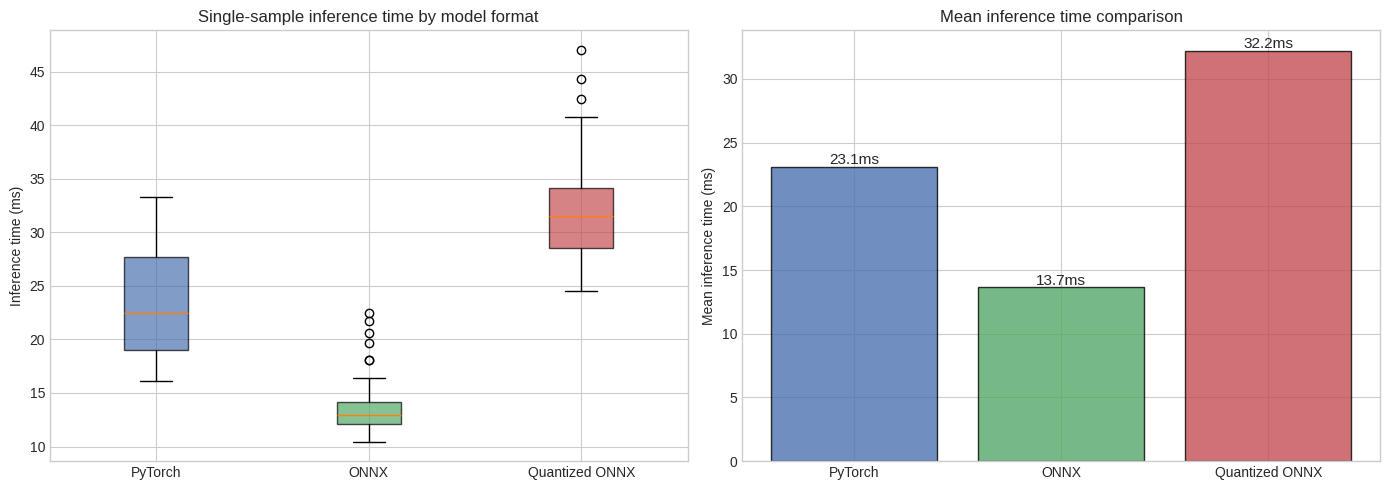

In [8]:
# Visualization
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

if results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Box plot
    ax = axes[0]
    data = list(results.values())
    labels = list(results.keys())
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True)
    colors = ['#4C72B0', '#55A868', '#C44E52']
    for patch, color in zip(bp['boxes'], colors[:len(data)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel('Inference time (ms)')
    ax.set_title('Single-sample inference time by model format')
    
    # Bar chart of means
    ax = axes[1]
    means = [np.mean(v) for v in results.values()]
    bars = ax.bar(labels, means, color=colors[:len(means)], edgecolor='black', alpha=0.8)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}ms', ha='center', fontsize=11)
    ax.set_ylabel('Mean inference time (ms)')
    ax.set_title('Mean inference time comparison')
    
    plt.tight_layout()
    plt.show()

## 5. Single model vs 5-model ensemble timing

In [9]:
# Compare 1-model vs 5-model ensemble inference time
# Use the fastest format available
if 'onnx' in model_formats:
    model_key = 'onnx'
    fmt_label = 'ONNX'
elif 'quantized' in model_formats:
    model_key = 'quantized'
    fmt_label = 'Quantized ONNX'
else:
    model_key = None
    fmt_label = 'N/A'

if model_key:
    model_paths = model_formats[model_key]
    
    # Load all available models
    sessions = []
    for p in model_paths:
        sessions.append(ort.InferenceSession(str(p), providers=['CPUExecutionProvider']))
    
    print(f'Loaded {len(sessions)} {fmt_label} models')
    
    # Benchmark: 1 model, 3 models, 5 models
    configs = [(1, 'Single model'), (3, '3-model ensemble'), (5, '5-model ensemble')]
    ensemble_results = {}
    
    for n_models, label in configs:
        if n_models > len(sessions):
            continue
        
        subset = sessions[:n_models]
        
        # Warmup
        for _ in range(N_WARMUP):
            for s in subset:
                s.run(None, {'input': dummy_input})
        
        # Bench
        times = []
        for _ in range(N_BENCH):
            t0 = time.perf_counter()
            logits_list = []
            for s in subset:
                logits_list.append(s.run(None, {'input': dummy_input})[0])
            # Average logits
            mean_logits = np.mean(logits_list, axis=0)
            times.append(time.perf_counter() - t0)
        
        times_ms = np.array(times) * 1000
        ensemble_results[label] = times_ms
        print(f'{label:>20}: mean={np.mean(times_ms):.2f}ms, '
              f'p95={np.percentile(times_ms, 95):.2f}ms')
    
    # Clean up
    del sessions
else:
    print('No ONNX models found — run export_onnx.py first')
    ensemble_results = {}

Loaded 5 ONNX models
        Single model: mean=12.50ms, p95=17.77ms
    3-model ensemble: mean=102.12ms, p95=138.11ms
    5-model ensemble: mean=174.52ms, p95=234.54ms


## 6. Full pipeline runtime estimation

In [10]:
# Estimate total runtime for the test set
# Typical BirdCLEF test: 100-200 soundscapes, each ~4 minutes = 48 windows

# Adjust these based on competition info
EST_N_SOUNDSCAPES = 200  # conservative estimate
EST_SOUNDSCAPE_DURATION_S = 240  # 4 minutes
EST_WINDOWS_PER_SOUNDSCAPE = EST_SOUNDSCAPE_DURATION_S // int(WINDOW_SECONDS)
EST_TOTAL_WINDOWS = EST_N_SOUNDSCAPES * EST_WINDOWS_PER_SOUNDSCAPE

print(f'Estimated test set:')
print(f'  Soundscapes: {EST_N_SOUNDSCAPES}')
print(f'  Duration each: {EST_SOUNDSCAPE_DURATION_S}s ({EST_SOUNDSCAPE_DURATION_S/60:.0f} min)')
print(f'  Windows per soundscape: {EST_WINDOWS_PER_SOUNDSCAPE}')
print(f'  Total windows: {EST_TOTAL_WINDOWS:,}')
print()

# Per-window costs
spec_ms = np.mean(spec_times) * 1000
audio_load_ms_per_window = np.mean(load_times) * 1000 / (SOUNDSCAPE_DURATION / WINDOW_SECONDS)

print(f'Per-window costs:')
print(f'  Audio load (amortized): {audio_load_ms_per_window:.2f}ms')
print(f'  Spectrogram:            {spec_ms:.2f}ms')
print()

# Estimate for different configurations
print(f'{"Configuration":<35} {"Inf/win (ms)":>12} {"Total (min)":>12} {"Fits 90min?":>12}')
print('-' * 75)

for label, times_ms in {**results, **ensemble_results}.items():
    inf_ms = np.mean(times_ms)
    total_ms_per_window = audio_load_ms_per_window + spec_ms + inf_ms
    total_seconds = (total_ms_per_window * EST_TOTAL_WINDOWS) / 1000
    total_minutes = total_seconds / 60
    fits = '✓ Yes' if total_minutes < 80 else ('⚠ Tight' if total_minutes < 90 else '✗ No')
    
    print(f'{label:<35} {inf_ms:>12.1f} {total_minutes:>12.1f} {fits:>12}')

print(f'\nBudget: 90 minutes total, targeting < 80 minutes for safety margin')

Estimated test set:
  Soundscapes: 200
  Duration each: 240s (4 min)
  Windows per soundscape: 48
  Total windows: 9,600

Per-window costs:
  Audio load (amortized): 67.45ms
  Spectrogram:            14.25ms

Configuration                       Inf/win (ms)  Total (min)  Fits 90min?
---------------------------------------------------------------------------
PyTorch                                     23.1         16.8        ✓ Yes
ONNX                                        13.7         15.3        ✓ Yes
Quantized ONNX                              32.2         18.2        ✓ Yes
Single model                                12.5         15.1        ✓ Yes
3-model ensemble                           102.1         29.4        ✓ Yes
5-model ensemble                           174.5         41.0        ✓ Yes

Budget: 90 minutes total, targeting < 80 minutes for safety margin


## 7. Memory profiling

In [11]:
# Memory usage profiling
import gc

def get_mem_mb():
    return psutil.Process().memory_info().rss / 1024 / 1024

gc.collect()
baseline_mem = get_mem_mb()
print(f'Baseline memory: {baseline_mem:.0f} MB')

# Load models one at a time and measure
if model_key:
    model_paths = model_formats[model_key]
    mem_per_model = []
    loaded_sessions = []
    
    for i, p in enumerate(model_paths):
        gc.collect()
        before = get_mem_mb()
        sess = ort.InferenceSession(str(p), providers=['CPUExecutionProvider'])
        loaded_sessions.append(sess)
        after = get_mem_mb()
        delta = after - before
        mem_per_model.append(delta)
        print(f'  Model {i}: +{delta:.0f} MB (total: {after:.0f} MB)')
    
    # Run inference to see peak memory
    gc.collect()
    pre_inference = get_mem_mb()
    
    for _ in range(10):
        for sess in loaded_sessions:
            sess.run(None, {'input': dummy_input})
    
    peak_inference = get_mem_mb()
    print(f'\nPeak during inference: {peak_inference:.0f} MB')
    print(f'Inference overhead: {peak_inference - pre_inference:.0f} MB')
    
    # Also estimate audio loading memory
    y_test = np.random.randn(SAMPLE_RATE * EST_SOUNDSCAPE_DURATION_S).astype(np.float32)
    audio_mem = y_test.nbytes / 1024 / 1024
    
    total_estimated = peak_inference + audio_mem + 200  # 200 MB buffer for pandas etc.
    kaggle_limit = 13 * 1024  # ~13 GB
    
    print(f'\nMemory estimate for Kaggle:')
    print(f'  Models ({len(loaded_sessions)}x {fmt_label}): ~{sum(mem_per_model):.0f} MB')
    print(f'  One soundscape audio buffer: ~{audio_mem:.0f} MB')
    print(f'  Overhead (pandas, etc.): ~200 MB')
    print(f'  Estimated total: ~{total_estimated:.0f} MB')
    print(f'  Kaggle limit: ~{kaggle_limit} MB')
    print(f'  Headroom: {kaggle_limit - total_estimated:.0f} MB')
    print(f'  Fits? {"✓ Yes" if total_estimated < kaggle_limit else "✗ No"}')
    
    del loaded_sessions
    gc.collect()

Baseline memory: 1137 MB
  Model 0: +38 MB (total: 1175 MB)
  Model 1: +19 MB (total: 1193 MB)
  Model 2: +23 MB (total: 1216 MB)
  Model 3: +16 MB (total: 1232 MB)
  Model 4: +22 MB (total: 1255 MB)

Peak during inference: 1351 MB
Inference overhead: 96 MB

Memory estimate for Kaggle:
  Models (5x ONNX): ~118 MB
  One soundscape audio buffer: ~29 MB
  Overhead (pandas, etc.): ~200 MB
  Estimated total: ~1580 MB
  Kaggle limit: ~13312 MB
  Headroom: 11732 MB
  Fits? ✓ Yes


## 8. Decision cell

Based on profiling results, determine the optimal inference strategy.

In [12]:
# ════════════════════════════════════════════════════════════════════
# DECISION: Optimal Inference Strategy
# ════════════════════════════════════════════════════════════════════

print('=' * 70)
print('INFERENCE STRATEGY DECISION')
print('=' * 70)

# Gather metrics
best_format = None
best_time = float('inf')

for label, times_ms in results.items():
    t = np.mean(times_ms)
    if t < best_time:
        best_time = t
        best_format = label

# Check what ensemble size fits
max_ensemble = 0
for label, times_ms in ensemble_results.items():
    inf_ms = np.mean(times_ms)
    total_ms = (audio_load_ms_per_window + spec_ms + inf_ms) * EST_TOTAL_WINDOWS
    total_min = total_ms / 1000 / 60
    n = int(label.split('-')[0]) if label[0].isdigit() else (1 if 'Single' in label else 5)
    if total_min < 80:
        max_ensemble = max(max_ensemble, n)

print(f'\n  Fastest format:         {best_format} ({best_time:.1f}ms/window)')
print(f'  Max safe ensemble size: {max_ensemble} models (within 80-min budget)')

# Final recommendation
if max_ensemble >= 5:
    strategy = '5-model ensemble'
    n_models = 5
elif max_ensemble >= 3:
    strategy = '3-model ensemble (drop 2 weakest folds)'
    n_models = 3
elif max_ensemble >= 1:
    strategy = 'Single best model (best fold by CV)'
    n_models = 1
else:
    strategy = 'CRITICAL: Pipeline too slow — optimize spectrogram computation'
    n_models = 1

use_quantized = 'Quantized' in (best_format or '')

print(f'\n  ┌──────────────────────────────────────────────────┐')
print(f'  │  RECOMMENDED STRATEGY                             │')
print(f'  │                                                    │')
print(f'  │  Format:     {best_format:<36} │')
print(f'  │  Ensemble:   {strategy:<36} │')
print(f'  │  Quantized:  {"Yes" if use_quantized else "No":<36} │')
print(f'  │  Models:     {n_models:<36} │')
print(f'  └──────────────────────────────────────────────────┘')

print(f'\nNext step: Use this strategy in the Kaggle submission notebook.')

INFERENCE STRATEGY DECISION

  Fastest format:         ONNX (13.7ms/window)
  Max safe ensemble size: 5 models (within 80-min budget)

  ┌──────────────────────────────────────────────────┐
  │  RECOMMENDED STRATEGY                             │
  │                                                    │
  │  Format:     ONNX                                 │
  │  Ensemble:   5-model ensemble                     │
  │  Quantized:  No                                   │
  │  Models:     5                                    │
  └──────────────────────────────────────────────────┘

Next step: Use this strategy in the Kaggle submission notebook.
